# Walmart Sales Analysis and Forecasting
---

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", palette="muted", context="paper")

from scipy.stats import ttest_ind
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

## Load the dataset

In [2]:
df = pd.read_csv(r"C:\Users\Bhawna\OneDrive\Desktop\Walmart sales forecasting using time series\Walmart_Sales.csv")

# Display top 5 rows
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## Data cleaning

In [3]:
# Checking null values
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [4]:
# Checking datatype
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [5]:
# Change date column object to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [6]:
# Check duplicates
duplicate_count = df.duplicated().sum()
print(f'Number of duplicates found: {duplicate_count}')

# Remove duplicates
df.drop_duplicates(inplace=True)
print(f'Shape of dataset after removing duplicates: {df.shape}')

Number of duplicates found: 0
Shape of dataset after removing duplicates: (6435, 8)


In [7]:
# Detect and remove outliers
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR 
upper_bound = Q3 + 1.5*IQR

outliers = df[(df['Weekly_Sales'] < lower_bound) | (df['Weekly_Sales'] > upper_bound)]
print(f'Number of outliers: {outliers.shape[0]}')

df = df[(df['Weekly_Sales'] > lower_bound) & (df['Weekly_Sales'] < upper_bound)]
print(f'Shape of dataset after removing outliers: {df.shape}')

Number of outliers: 34
Shape of dataset after removing outliers: (6401, 8)


In [8]:
# Show summary stats after outlier removal
print("Show summary statistics after outlier removal: ")
print(round(df['Weekly_Sales'].describe(), 2))

Show summary statistics after outlier removal: 
count       6401.00
mean     1036130.35
std       545196.06
min       209986.25
25%       551743.05
50%       957298.26
75%      1414564.53
max      2685351.81
Name: Weekly_Sales, dtype: float64


## Exploratory Data Analysis

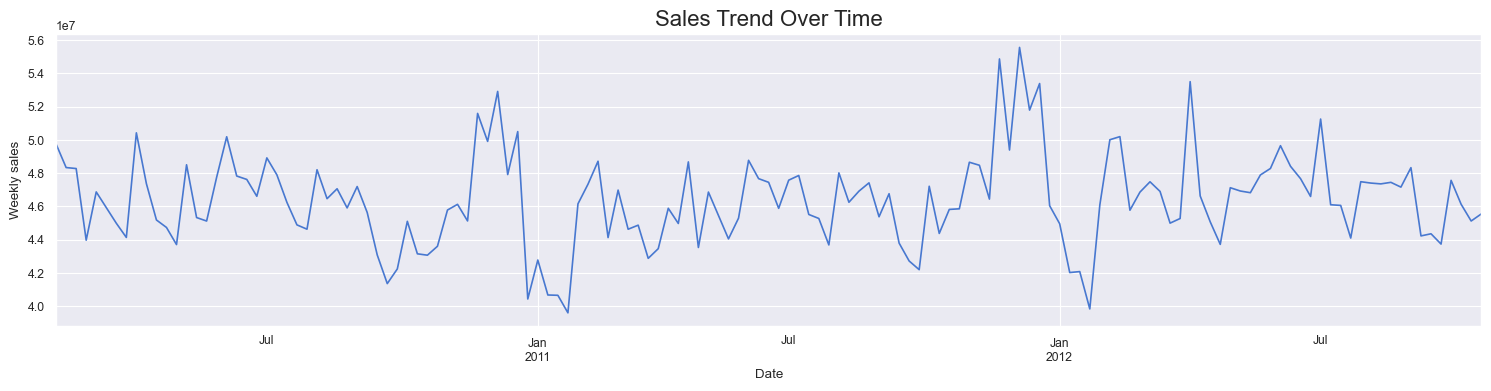

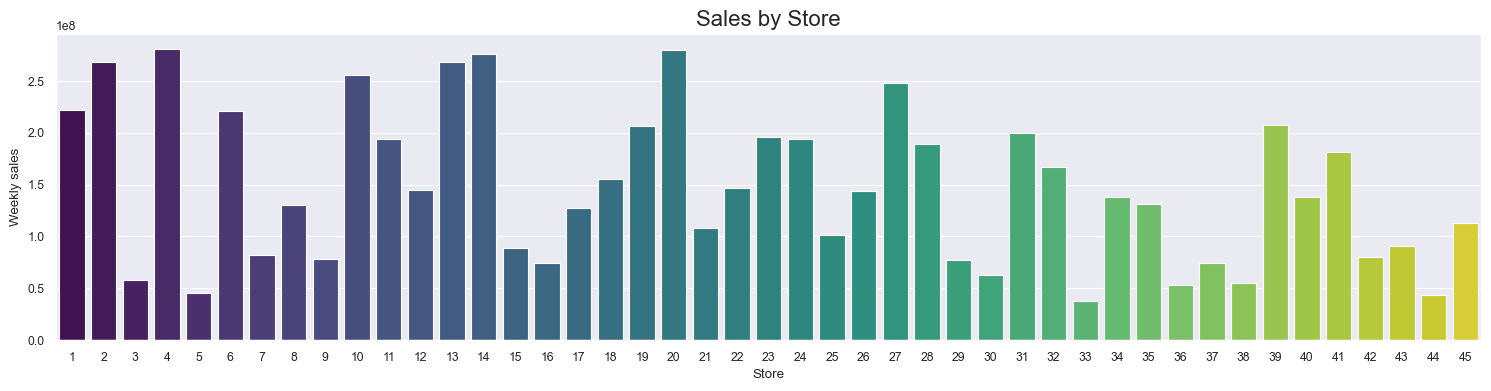

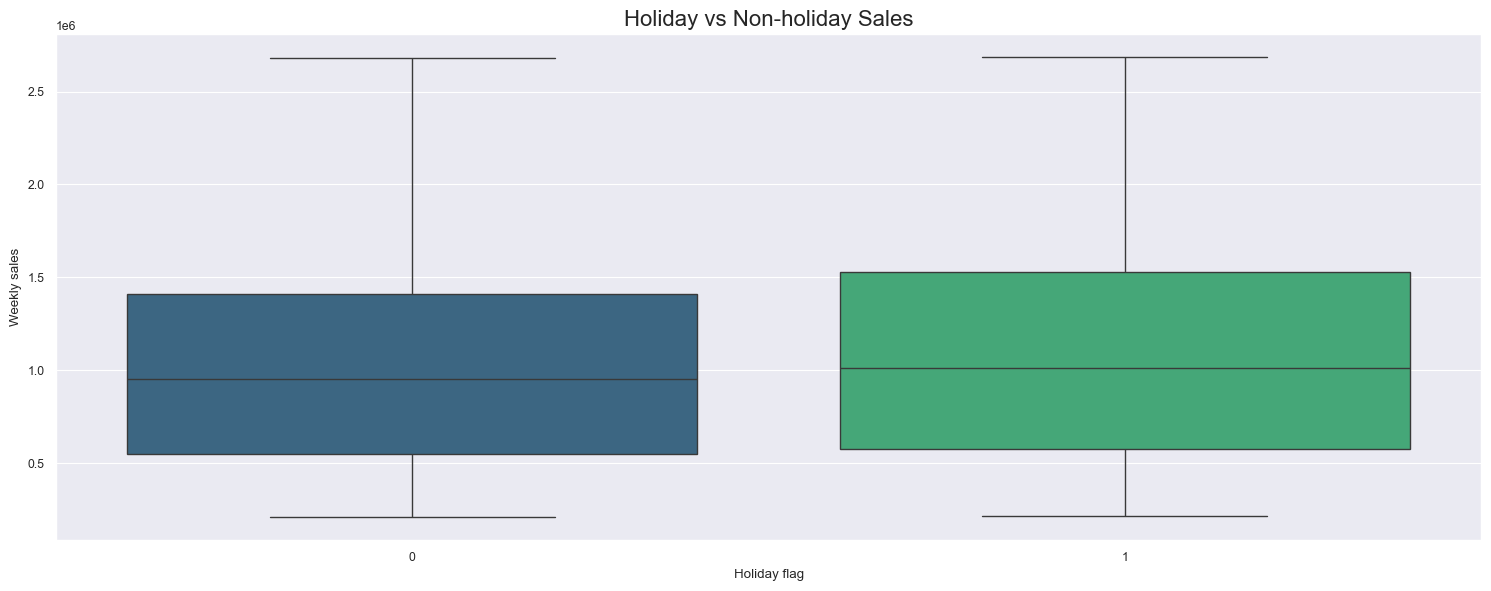

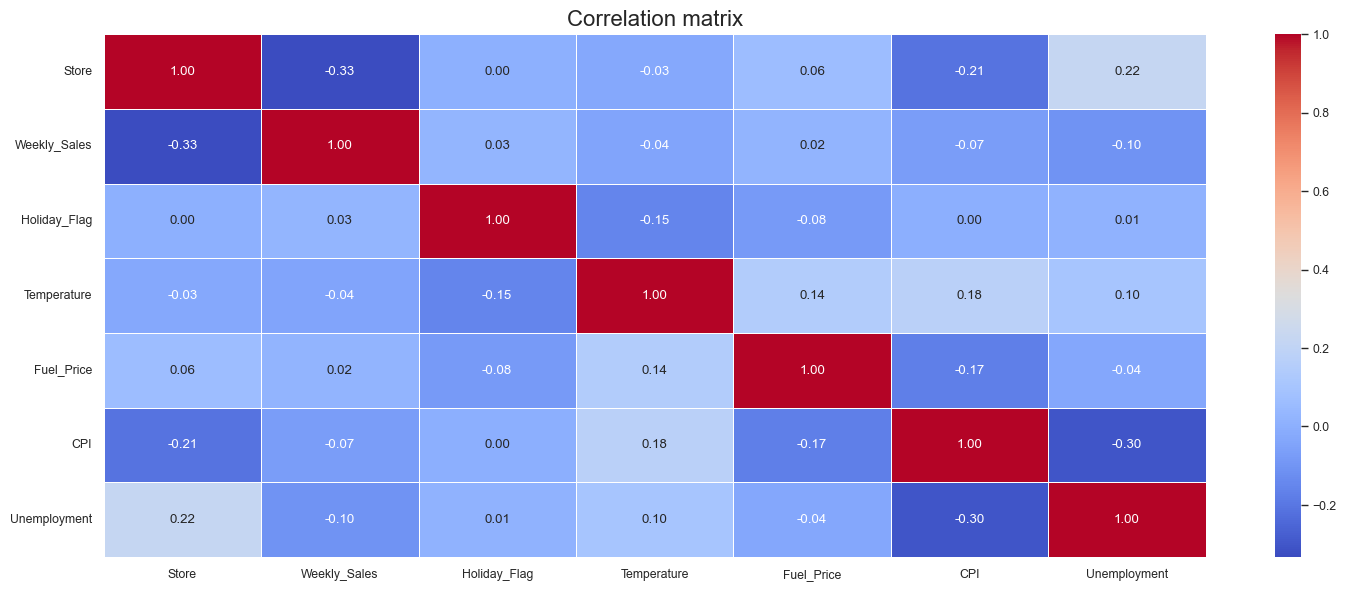

In [9]:
# Sales trend over time
plt.figure(figsize=(15,4))
df.groupby(['Date'])['Weekly_Sales'].sum().plot()
plt.title("Sales Trend Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Weekly sales")
plt.tight_layout()
plt.show()

# Sales by store
store_sales = df.groupby(['Store'])['Weekly_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(15,4))
sns.barplot(x = store_sales.index, y = store_sales.values, palette='viridis')
plt.title("Sales by Store", fontsize=16)
plt.xlabel("Store")
plt.ylabel("Weekly sales")
plt.tight_layout()
plt.show()

# Holiday vs Non- holiday sales
plt.figure(figsize=(15,6))
sns.boxplot(x=df['Holiday_Flag'], y=df['Weekly_Sales'], palette='viridis')
plt.title("Holiday vs Non-holiday Sales", fontsize=16)
plt.xlabel("Holiday flag")
plt.ylabel("Weekly sales")
plt.tight_layout()
plt.show()

# Correlation Matrix
numeric_df = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(15,6))
sns.heatmap(numeric_df.corr(), annot = True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation matrix", fontsize=16)
plt.tight_layout()
plt.show()

## Descriptive and Statistical Analysis

In [10]:
# Descriptive stats
print("Descriptive statistics for numerical columns: \n")
print(df.describe(include=[np.number]))

# T-test of Holiday vs Non-holiday sales
holiday_sales = df[df['Holiday_Flag']==1]['Weekly_Sales']
non_holiday_sales = df[df['Holiday_Flag']==0]['Weekly_Sales']

t_stat, p_value = ttest_ind(holiday_sales, non_holiday_sales, equal_var=False)
print("T-test: Holiday vs Non-holiday Sales: ")
print(f"\nT-Statistics: {t_stat:.2f}")
print(f"\nP-Value: {p_value:.4e}")

if p_value < 0.05:
    print("Significant difference between holiday and non holiday sales.")
else:
    print("NO significant difference between holiday and non holiday sales.")

Descriptive statistics for numerical columns: 

             Store  Weekly_Sales  ...          CPI  Unemployment
count  6401.000000  6.401000e+03  ...  6401.000000   6401.000000
mean     23.054210  1.036130e+06  ...   171.642219      8.002298
std      12.991284  5.451961e+05  ...    39.359852      1.878705
min       1.000000  2.099862e+05  ...   126.064000      3.879000
25%      12.000000  5.517431e+05  ...   131.784000      6.891000
50%      23.000000  9.572983e+05  ...   182.658578      7.874000
75%      34.000000  1.414565e+06  ...   212.833640      8.622000
max      45.000000  2.685352e+06  ...   227.232807     14.313000

[8 rows x 7 columns]
T-test: Holiday vs Non-holiday Sales: 

T-Statistics: 1.91

P-Value: 5.6314e-02
NO significant difference between holiday and non holiday sales.


## Time Series Forecasting

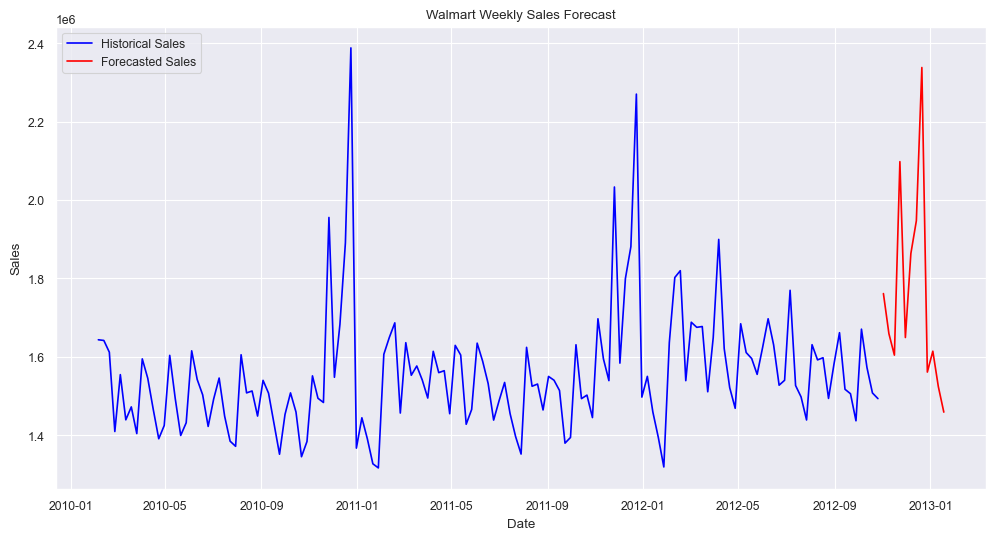

In [11]:
# Selecting any 1 store for forecasting
data = df[df['Store']==1].groupby('Date')['Weekly_Sales'].sum().reset_index()
data = data.set_index('Date')

# Step 3: Build SARIMA model
model = SARIMAX(data['Weekly_Sales'],
                                  order=(1,1,1),
                                  seasonal_order=(1,1,1,52), # yearly seasonality (52 weeks)
                                  enforce_stationarity=False,
                                  enforce_invertibility=False)

results = model.fit()

# Step 4: Forecast next 12 weeks
forecast = results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Step 5: Visualization
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Weekly_Sales'], color='blue', label='Historical Sales')
plt.plot(forecast_mean.index, forecast_mean, color='red', label='Forecasted Sales')
plt.title("Walmart Weekly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()


In [14]:
# Features and target
x = df.drop(['Weekly_Sales','Date','Store'], axis=1)
y = df['Weekly_Sales']

# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

# Linear Regression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

# Evaluate model
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2:.2f}')

# Regression coefficients
coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': lr.coef_
})
print("Regression Coefficients: \n")
print(coef_df)

R2 Score: 0.02
Regression Coefficients: 

        Feature   Coefficient
0  Holiday_Flag  55965.512790
1   Temperature     37.401175
2    Fuel_Price -15207.625359
3           CPI  -1556.077415
4  Unemployment -41957.173596


## Thank You